<a href="https://colab.research.google.com/github/Adrian-Ang012/Eskwelab-Aviation-Revenue-Ancillary-Attach-Pricing-Simulation/blob/main/data_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uuid
import datetime
import os

In [ ]:
CONFIG = {
    "N_SAMPLES": 1_000_000,
    "ELENA_CEILING_THETA": 0.25,
    "KAPPA_ELASTICITY": 2.2,
    "BETA_LOW": -0.05,
    "DELTA_REINFORCE": 0.45,
    "GAMMA_CANNIBAL": -0.60,
    "BETA_URGENCY": 0.30,

    "BETA_RANK": -0.15,
    "BETA_SCARCITY": 0.25
}

In [ ]:
class AncillaryDataGenerator:
    def __init__(self, config):
        self.cfg = config
        self.n = config['N_SAMPLES']
        self.bookings = None
        self.offers = []
        self.conversions = []

    def generate_base_context(self):
        persona = np.random.choice(['Business', 'Leisure', 'VFR'], self.n, p=[0.2, 0.5, 0.3])

        base_fares = np.where(persona == 'Business',
                              np.random.uniform(600, 1200, self.n),
                              np.random.uniform(150, 500, self.n))

        self.bookings = pd.DataFrame({
            'booking_id': [str(uuid.uuid4()) for _ in range(self.n)],
            'market_segment': persona,
            'channel': np.random.choice(['Direct', 'OTA', 'GDS'], self.n, p=[0.5, 0.3, 0.2]),
            'days_to_dep': np.random.poisson(14, self.n),
            'base_fare_amt': base_fares,
            'load_factor': np.random.uniform(0.4, 0.98, self.n)
        })


    def number_of_rows(self, total_n, chunk_size=1000000):
        num_chunks = total_n // chunk_size
        remainder = total_n % chunk_size


        for f in ['dim_bookings.csv', 'fact_offers.csv', 'fact_conversions.csv']:
            if os.path.exists(f): os.remove(f)

        total_chunks = num_chunks + (1 if remainder > 0 else 0)

        for i in range(total_chunks):
            current_batch_n = chunk_size if i < num_chunks else remainder
            if current_batch_n == 0: continue


            self.offers = []
            self.conversions = []

            print(f"Generating batch {i+1}/{total_chunks} ({current_batch_n} rows)...")


            self.generate_base_context()
            self.simulate_ancillary_stage("Baggage", (25, 55), 0.2)
            self.simulate_ancillary_stage("Seat", (15, 45), -0.5)
            self.simulate_ancillary_stage("Meal", (10, 25), -1.2)

            #
            df_b, df_o, df_c = self.get_final_data()


            is_first = (i == 0)
            df_b.to_csv('dim_bookings.csv', mode='a', index=False, header=is_first)
            df_o.to_csv('fact_offers.csv', mode='a', index=False, header=is_first)
            df_c.to_csv('fact_conversions.csv', mode='a', index=False, header=is_first)


            del df_b, df_o, df_c

        print(f"Success! {total_n} rows generated across 3 CSV files.")

    def simulate_ancillary_stage(self, stage_name, price_range, base_utility):
        prices = np.random.uniform(price_range[0], price_range[1], self.n)
        inv_rem = np.random.randint(1, 20, self.n)
        ranks = np.random.choice([1, 2, 3], self.n)

        reinforcement = np.zeros(self.n)
        if len(self.conversions) > 0:
            prior_stage = self.conversions[-1]
            reinforcement = prior_stage['is_purchased'] * self.cfg['DELTA_REINFORCE']

        threshold = self.cfg['ELENA_CEILING_THETA'] * self.bookings['base_fare_amt']
        beta_p = np.where(prices <= threshold,
                          self.cfg['BETA_LOW'],
                          self.cfg['BETA_LOW'] * self.cfg['KAPPA_ELASTICITY'])

        channel_mult = np.where(self.bookings['channel'] == 'OTA', 1.25, 1.0)

        V = (base_utility +
             (beta_p * channel_mult * prices) +
             (self.cfg['BETA_URGENCY'] * (1 / (self.bookings['days_to_dep'] + 1))) +
             (self.cfg['BETA_RANK'] * ranks) +
             (self.cfg['BETA_SCARCITY'] * (1 / (inv_rem + 1))) +
             reinforcement)

        prob = 1 / (1 + np.exp(-V))
        is_purchased = np.random.binomial(1, prob)

        stage_offer_ids = [str(uuid.uuid4()) for _ in range(self.n)]

        self.offers.append(pd.DataFrame({
            'offer_id': stage_offer_ids,
            'booking_id': self.bookings['booking_id'],
            'ancillary_type': stage_name,
            'offer_price': np.round(prices, 2),
            'display_rank': ranks,
            'inventory_rem': inv_rem
        }))



        self.conversions.append(pd.DataFrame({
            'conversion_id': [str(uuid.uuid4()) for _ in range(self.n)],
            'offer_id': stage_offer_ids,
            'is_purchased': is_purchased,

            'timestamp': [datetime.datetime.now(datetime.timezone.utc) for _ in range(self.n)]
        }))

    def inject_messiness(self, df_conv):
        n_dupes = int(len(df_conv) * 0.005)
        dupes = df_conv.sample(n_dupes).copy()
        dupes['timestamp'] = dupes['timestamp'] + pd.to_timedelta(np.random.randint(5, 20, n_dupes), unit='ms')
        return pd.concat([df_conv, dupes]).reset_index(drop=True)

    def get_final_data(self):
        df_c = pd.concat(self.conversions).reset_index(drop=True)
        df_c = self.inject_messiness(df_c)
        return (self.bookings,
                pd.concat(self.offers).reset_index(drop=True),
                df_c)


In [ ]:
engine = AncillaryDataGenerator(CONFIG)
engine.generate_base_context()
engine.simulate_ancillary_stage("Baggage", (25, 55), base_utility=0.2)
engine.simulate_ancillary_stage("Seat", (15, 45), base_utility=-0.5)
engine.simulate_ancillary_stage("Meal", (10, 25), base_utility=-1.2)

df_bookings, df_offers, df_conversions = engine.get_final_data()

/tmp/ipykernel_783/2121006430.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby(pd.cut(merged['price_to_fare_ratio'], bins=20))['is_purchased'].mean().plot(kind='line', marker='o')


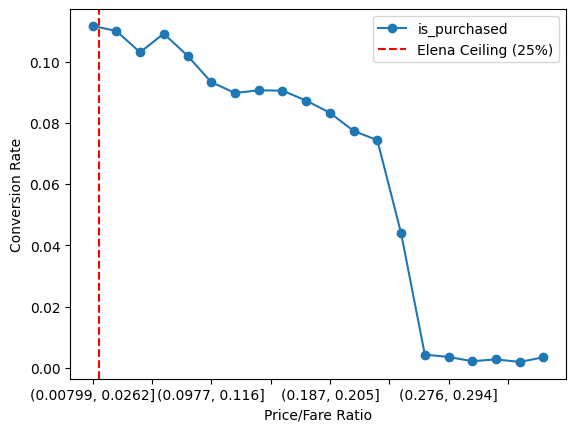

In [ ]:
merged = df_offers.merge(df_bookings, on='booking_id').merge(df_conversions, on='offer_id')
merged['price_to_fare_ratio'] = merged['offer_price'] / merged['base_fare_amt']

merged.groupby(pd.cut(merged['price_to_fare_ratio'], bins=20))['is_purchased'].mean().plot(kind='line', marker='o')
plt.axvline(x=0.25, color='red', linestyle='--', label='Elena Ceiling (25%)')
plt.ylabel('Conversion Rate')
plt.xlabel('Price/Fare Ratio')
plt.legend()
plt.show()

In [ ]:
full_results = df_offers.merge(df_conversions, on='offer_id')

bag_purchasers = full_results[
    (full_results['ancillary_type'] == 'Baggage') &
    (full_results['is_purchased'] == 1)
]['booking_id'].unique()

seat_offers = full_results[full_results['ancillary_type'] == 'Seat'].copy()
seat_offers['bought_bag_prior'] = seat_offers['booking_id'].isin(bag_purchasers)

lift_analysis = seat_offers.groupby('bought_bag_prior')['is_purchased'].mean()

print("--- Basket Reinforcement Analysis ---")
print(f"Seat Conv Rate (No Bag):   {lift_analysis[False]:.2%}")
print(f"Seat Conv Rate (With Bag): {lift_analysis[True]:.2%}")
print(f"Observed Lift:             {(lift_analysis[True]/lift_analysis[False] - 1):.2%}")

--- Basket Reinforcement Analysis ---
Seat Conv Rate (No Bag):   9.45%
Seat Conv Rate (With Bag): 14.10%
Observed Lift:             49.18%


## 🗺️ RUNNING THE GENERATOR
To run the dataset generator

1. Instantiate first the main function AncillaryDataSetGenerator(CONFIG)
2. Determine the number of rows you want to generate as the variable n.
(n = 10, 1000, 10000000, 1000000)
3. use the function number_of_rows(n)

## 🗺️ EXAMPLE

1. engine - AncillaryDataGenerator(CONFIG)
2. engine.number_of_rows(n) ; where n is the number of rows

In [ ]:
engine = AncillaryDataGenerator(CONFIG)

engine.number_of_rows(100000000000)

df_bookings_preview = pd.read_csv('dim_bookings.csv', nrows=100)
display(df_bookings_preview.head())

Generating batch 1/100000 (1000000 rows)...


KeyboardInterrupt: 

Now that the simulation is complete, we need to export the generated datasets. This step saves the processed bookings, offers, and conversions tables into CSV files. These files will serve as the input for our Showcase & Analysis Notebook, allowing us to perform EDA and machine learning model validation without needing to re-run the heavy simulation engine.

In [ ]:
df_bookings.to_csv('dim_bookings.csv', index=False)
df_offers.to_csv('fact_offers.csv', index=False)
df_conversions.to_csv('fact_conversions.csv', index=False)

from google.colab import drive
drive.mount('/content/drive')
!cp *.csv /content/drive/MyDrive/Eskwelab_Data/